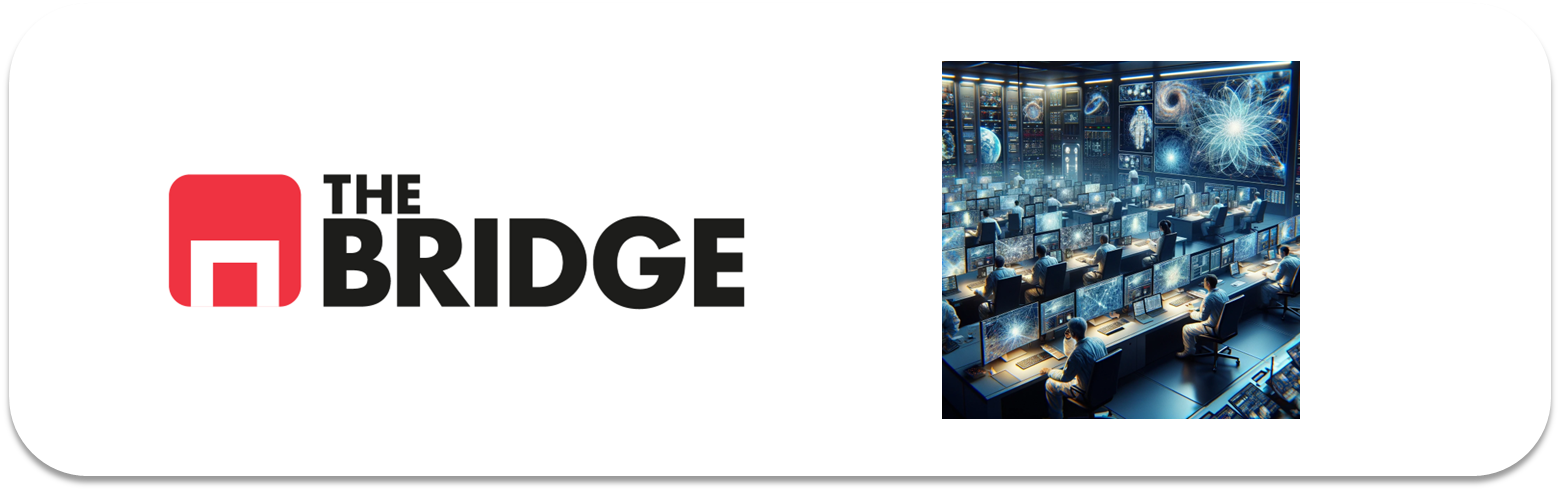

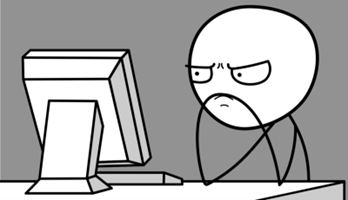

Para ejercitarte y afianzar lo aprendido sobre **Redes Convolucionales**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import cv2
from skimage.io import imread

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from keras.optimizers import Adam

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.21.0


## El problema de "Negocio"
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en https://www.kaggle.com/datasets/puneet6060/intel-image-classification?select=seg_test como `seg_train.zip` y `seg_test.zip` (o bien en el botón de download).  

NOTA: Son archivos bastante grandes (386MB en total). Por supuesto, no es necesario que tengas que mantenerlos en tu ordenador una vez realizado el ejercicio, bórralos si es el caso.




### Ejercicio 1

Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones). Para ello:

1. Descarga las imagenes del repositorio de Kaggle en el directorio que vayas a emplear para el ejercicio.
2. Descomprime los datos (son ficheros de imágenes) de forma que tengas dos subdirectorios seg_train y seg_test en el que estén ya colgando directamente los directorios de cada clase de paisajes. Si descargaste seg_pred, puedes eliminarlo.
3. Crea unas variables como las siguientes (ajustándolas a tu caso/rutas particulares):

```python
ROOT_PATH = './data/'
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"
```
4. Utiliza la siguiente función para crear los X_train, y_train y X_test e y_test:

```python
def read_data(directorio, reshape_dim = (32,32)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 32x32

                X.append(image)
                y.append(folder)

    return np.array(X),np.array(y)
```


*Pues copiamos lo que nos dicen y lo aplicamos a los dos directorios para tener las X y las y*

In [2]:
ROOT_PATH  = './data/'
TRAIN_PATH = ROOT_PATH + 'seg_train/'
TEST_PATH  = ROOT_PATH + 'seg_test/'

def read_data(directorio, reshape_dim=(32, 32)):
    """
    Recorre las subcarpetas de 'directorio'.
    Cada subcarpeta es una clase (buildings, forest, glacier, mountain, sea, street).
    Carga cada imagen, la redimensiona y la etiqueta con el nombre de la carpeta.
    """
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):
                try:
                    image = imread('/'.join([directorio, folder, file]))
                    image = cv2.resize(image, reshape_dim)  # Redimensionamos las imágenes a 32x32
                    X.append(image)
                    y.append(folder)
                except Exception as e:
                    print(f'Error leyendo {file}: {e}')
    return np.array(X), np.array(y)


print('Cargando train...')
X_train_raw, y_train_str = read_data(TRAIN_PATH, reshape_dim=(32, 32))

print('Cargando test...')
X_test_raw, y_test_str = read_data(TEST_PATH, reshape_dim=(32, 32))

print(f'\nX_train: {X_train_raw.shape}  |  y_train: {y_train_str.shape}')
print(f'X_test:  {X_test_raw.shape}   |  y_test:  {y_test_str.shape}')

Cargando train...
Cargando test...

X_train: (14034, 32, 32, 3)  |  y_train: (14034,)
X_test:  (3000, 32, 32, 3)   |  y_test:  (3000,)


### Ejercicio 2

Haz la visualización del dataset: comprueba cuantos datos tienes, que forma, investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.


=== Dimensiones ===
Train: (14034, 32, 32, 3)  ->  14034 imágenes de 32x32 px, 3 canales (RGB)
Test:  (3000, 32, 32, 3)

Clases: [np.str_('buildings'), np.str_('forest'), np.str_('glacier'), np.str_('mountain'), np.str_('sea'), np.str_('street')]
Número de clases: 6


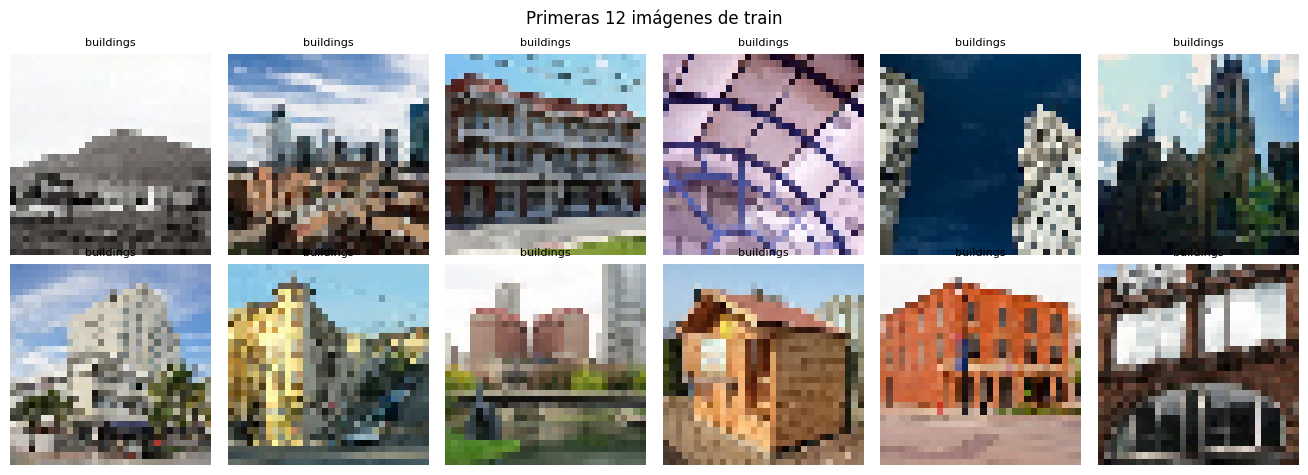

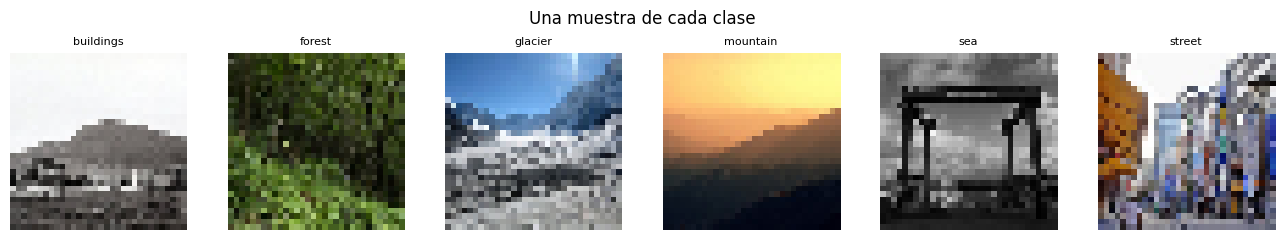

In [3]:
# ── Dimensiones generales ──────────────────────────────────
print('=== Dimensiones ===')
print(f'Train: {X_train_raw.shape}  ->  {X_train_raw.shape[0]} imágenes de '
      f'{X_train_raw.shape[1]}x{X_train_raw.shape[2]} px, {X_train_raw.shape[3]} canales (RGB)')
print(f'Test:  {X_test_raw.shape}')
print(f'\nClases: {sorted(np.unique(y_train_str))}')
print(f'Número de clases: {len(np.unique(y_train_str))}')

# ── Función de visualización ────────────────────────────────
def plot_images(X, y, indices, n_cols=6, title=None):
    n_rows = (len(indices) - 1) // n_cols + 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.2, n_rows * 2.4))
    axes = np.array(axes).flatten()
    for ax, idx in zip(axes, indices):
        ax.imshow(X[idx])
        ax.set_title(y[idx], fontsize=8)
        ax.axis('off')
    for ax in axes[len(indices):]:
        ax.axis('off')
    if title:
        fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

# Primeras 12 imágenes de train
plot_images(X_train_raw, y_train_str, range(12), title='Primeras 12 imágenes de train')

# Una muestra de cada clase para verificar la carga
CLASS_NAMES = sorted(np.unique(y_train_str))
sample_idx = [np.where(y_train_str == c)[0][0] for c in CLASS_NAMES]
plot_images(X_train_raw, y_train_str, sample_idx,
            n_cols=len(CLASS_NAMES), title='Una muestra de cada clase')

### Ejercicio 3

Ahora haz un pequeño miniEda y normaliza las features



=== TRAIN — distribución del target ===
buildings    2191
forest       2271
glacier      2404
mountain     2512
sea          2274
street       2382
Name: count, dtype: int64

buildings    0.156
forest       0.162
glacier      0.171
mountain     0.179
sea          0.162
street       0.170
Name: proportion, dtype: float64

=== TEST — distribución del target ===
buildings    437
forest       474
glacier      553
mountain     525
sea          510
street       501
Name: count, dtype: int64


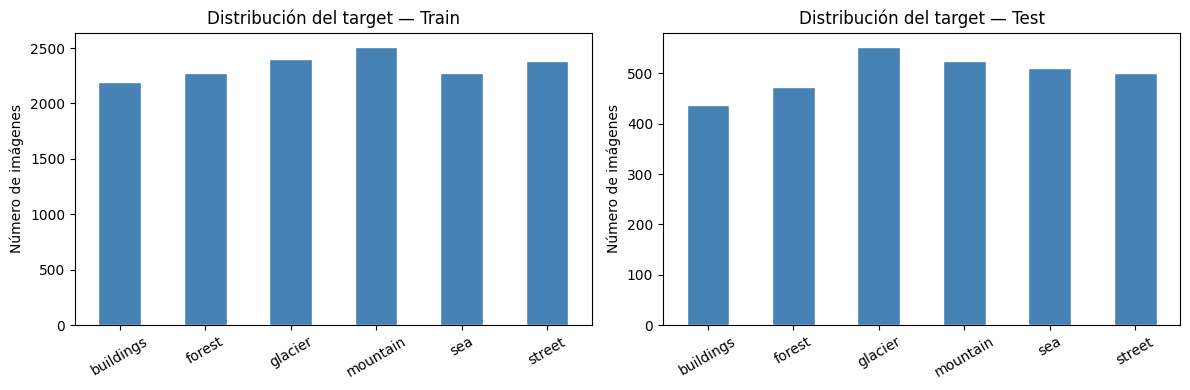


Rango tras escalado — min: 0.0  max: 1.0
Clases codificadas: {np.str_('buildings'): np.int64(0), np.str_('forest'): np.int64(1), np.str_('glacier'): np.int64(2), np.str_('mountain'): np.int64(3), np.str_('sea'): np.int64(4), np.str_('street'): np.int64(5)}
y_train shape: (14034,)  dtype: int64


In [4]:
# ── MiniEDA: distribución del target ────────────────────────
print('=== TRAIN — distribución del target ===')
train_counts = pd.Series(y_train_str).value_counts().sort_index()
print(train_counts)
print()
print(pd.Series(y_train_str).value_counts(normalize=True).sort_index().round(3))

print('\n=== TEST — distribución del target ===')
print(pd.Series(y_test_str).value_counts().sort_index())

# Gráfico de distribución
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, split in zip(axes,
    [pd.Series(y_train_str).value_counts().sort_index(),
     pd.Series(y_test_str).value_counts().sort_index()],
    ['Train', 'Test']):
    ax.bar(counts.index, counts.values, color='steelblue', width=0.5, edgecolor='white')
    ax.set_title(f'Distribución del target — {split}')
    ax.set_ylabel('Número de imágenes')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# El dataset está bastante equilibrado -> accuracy es una métrica adecuada

# ── Escalado: dividimos entre 255 ───────────────────────────
# Mismo truco que en el workout: los píxeles van de 0 a 255.
# Dividir entre 255 equivale a un MinMaxScaler y deja los valores en [0,1].
# Ejecutar solo una vez.
X_train = X_train_raw.astype('float32') / 255
X_test  = X_test_raw.astype('float32')  / 255

print(f'\nRango tras escalado — min: {X_train.min():.1f}  max: {X_train.max():.1f}')

# ── Codificación del target ──────────────────────────────────
# Las etiquetas son strings (nombres de carpeta).
# Las convertimos a enteros con LabelEncoder para usar sparse_categorical_crossentropy.
le = LabelEncoder()
y_train = le.fit_transform(y_train_str)   # fit solo sobre train
y_test  = le.transform(y_test_str)

print(f'Clases codificadas: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print(f'y_train shape: {y_train.shape}  dtype: {y_train.dtype}')

### Ejercicio 4

Diseña la arquitectura de la red. Recuerda que es un algiritmo de clasificación. Ojo con las dimensiones de la entrada. Como guía, copia o parte de la arquitectura del workout (un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer)


In [5]:
# Misma estructura que el workout: dos bloques Conv2D-MaxPool-Dropout + cabeza densa.
#
# Diferencias respecto al workout (MNIST 28x28 un canal):
#   - input_shape = (32, 32, 3)  <- RGB, 3 canales
#   - Salida: 6 neuronas (una por clase) + softmax
#
# Flujo de resolución:
#   Conv2D(32, 5x5, Same)  -> 32x32x32
#   MaxPool2D(2x2)         -> 16x16x32
#   Conv2D(64, 3x3, Same)  -> 16x16x64
#   MaxPool2D(2x2)         ->  8x8x64
#   Flatten                ->  8*8*64 = 4096 features
#   Dense(256) -> Dense(6, softmax)

NUM_CLASSES = len(le.classes_)  # 6

model = Sequential()

# ── Bloque convolucional 1 ──────────────────────────────────
model.add(Conv2D(filters=32, kernel_size=(5, 5), padding='Same',
                 activation='relu', input_shape=(32, 32, 3)))
# padding='Same' + stride(1,1) -> resolución se mantiene: 32x32x32
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
# Resolución: 16x16x32
model.add(Dropout(rate=0.25))

# ── Bloque convolucional 2 ──────────────────────────────────
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='Same',
                 activation='relu'))
# Resolución: 16x16x64
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
# Resolución: 8x8x64
model.add(Dropout(rate=0.25))

# ── Cabeza densa ────────────────────────────────────────────
print('Entrada a la capa Flatten:', model.output_shape)
model.add(Flatten())  # 8*8*64 = 4096 features
print('Salida de la capa Flatten:', model.output_shape)
model.add(Dense(256, activation='relu'))
model.add(Dropout(rate=0.5))  # Dropout más agresivo antes de la salida
model.add(Dense(NUM_CLASSES, activation='softmax'))  # 6 neuronas, softmax

print(f'\nPesos de la capa Conv 1: {32 * (5*5*3 + 1)}  (32 filtros x (5x5x3 canales + 1 bias))')
print(f'Pesos de la capa Conv 2: {64 * (3*3*32 + 1)}  (64 filtros x (3x3x32 + 1 bias))')

Entrada a la capa Flatten: (None, 8, 8, 64)
Salida de la capa Flatten: (None, 4096)

Pesos de la capa Conv 1: 2432  (32 filtros x (5x5x3 canales + 1 bias))
Pesos de la capa Conv 2: 18496  (64 filtros x (3x3x32 + 1 bias))


### Ejercicio 5

Escoge el resto de hiperparámetros (optimizador, learning_rate, función de pérdida, métrica,...) y compila el modelo. Muestra un resumen del mismo

In [6]:
# ── Optimizador ─────────────────────────────────────────────
# Adam: elección habitual con datasets grandes.
# learning_rate=0.001: buen punto de partida (warm-up moderado).
# beta_1=0.9, beta_2=0.999: valores por defecto, no haría falta indicarlos.
optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

# ── Compilación ──────────────────────────────────────────────
# Loss: sparse_categorical_crossentropy porque el target es un entero
#       (si fuera one-hot usaríamos categorical_crossentropy)
# Métrica: accuracy, válida porque el dataset está equilibrado
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,071,302 (4.09 MB)

 Trainable params: 1,071,302 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 6

Entrena el modelo reservando un 20% de los datos del entrenamiento para validar y con los callbacks que creas necesarios. NOTA: Ojo, tendrás que preparar un poco los X,y antes.



In [7]:
# Comprobamos que las X,y tienen la forma que espera Keras
print('X_train shape:', X_train.shape)   # (n, 32, 32, 3)  float32
print('y_train dtype:', y_train.dtype)   # int — necesario para sparse_categorical_crossentropy

batch_size       = 128
epochs           = 50      # EarlyStopping parará antes si procede
validation_split = 0.2

# EarlyStopping: para cuando val_loss no mejora durante 'patience' épocas
# y restaura los pesos de la mejor época (restore_best_weights=True)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
    callbacks=[early_stop],
    verbose=1
)

print(f'\nEntrenamiento detenido en la época {len(history.epoch)}')

X_train shape: (14034, 32, 32, 3)
y_train dtype: int64
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5576 - loss: 1.1125 - val_accuracy: 0.0299 - val_loss: 5.0184
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6715 - loss: 0.8518 - val_accuracy: 0.0431 - val_loss: 7.0025
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7058 - loss: 0.7764 - val_accuracy: 0.0702 - val_loss: 7.3359
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7241 - loss: 0.7317 - val_accuracy: 0.0855 - val_loss: 7.6683
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7496 - loss: 0.6743 - val_accuracy: 0.0805 - val_loss: 8.8883
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7650 - loss: 0.6422 - val_accuracy: 0.0627 - val_loss: 8.7758

Entrenamiento detenido en la época 6



### Ejercicio 7

Representa el objeto history y comenta la evolución de tu entrenamiento.



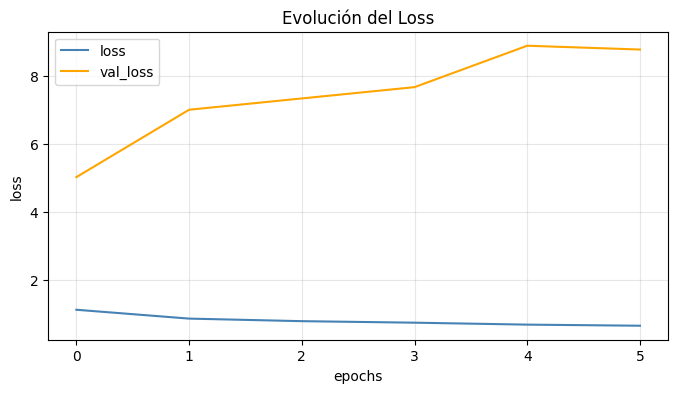

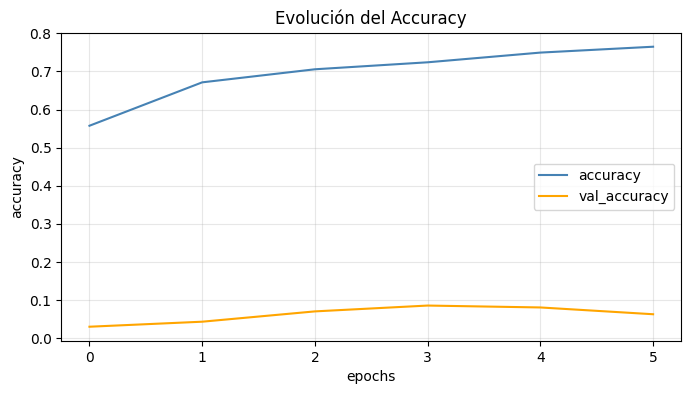

   accuracy    loss  val_accuracy  val_loss
0    0.5576  1.1125        0.0299    5.0184
1    0.6715  0.8518        0.0431    7.0025
2    0.7058  0.7764        0.0702    7.3359
3    0.7241  0.7317        0.0855    7.6683
4    0.7496  0.6743        0.0805    8.8883
5    0.7650  0.6422        0.0627    8.7758


In [8]:
history_df = pd.DataFrame(history.history)

# ── Loss ────────────────────────────────────────────────────
history_df[['loss', 'val_loss']].plot(figsize=(8, 4), color=['steelblue', 'orange'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Evolución del Loss')
plt.grid(True, alpha=0.3)
plt.show()

# ── Accuracy ─────────────────────────────────────────────────
history_df[['accuracy', 'val_accuracy']].plot(figsize=(8, 4), color=['steelblue', 'orange'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Evolución del Accuracy')
plt.grid(True, alpha=0.3)
plt.show()

print(history_df.round(4).to_string())


### Ejercicio 8

Evalua el modelo con los datos de test, además muestra el report de clasificación y la matriz de confusión.



Test loss:     1.7015
Test accuracy: 0.5190  (51.90%)
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Classification Report
              precision    recall  f1-score   support

   buildings       0.44      0.61      0.51       437
      forest       0.69      0.86      0.77       474
     glacier       0.52      0.62      0.56       553
    mountain       0.45      0.82      0.58       525
         sea       0.66      0.21      0.32       510
      street       0.00      0.00      0.00       501

    accuracy                           0.52      3000
   macro avg       0.46      0.52      0.46      3000
weighted avg       0.46      0.52      0.45      3000



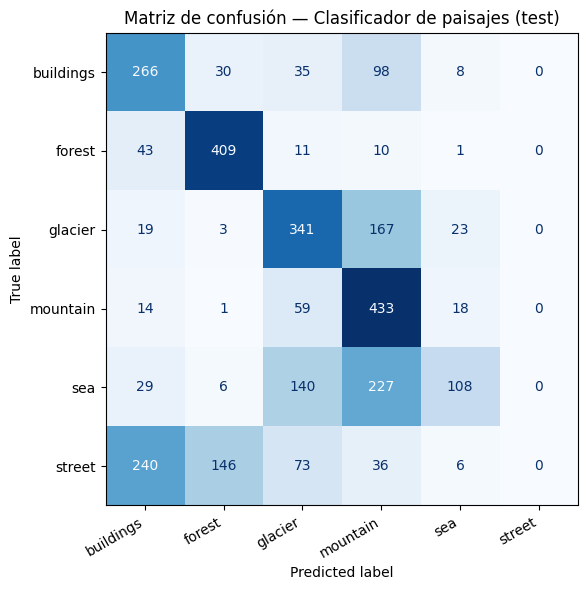

In [9]:
# ── Evaluación sobre test ────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss:     {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')

# ── Predicciones ─────────────────────────────────────────────
# argmax sobre las probabilidades softmax -> clase predicha
y_pred = [np.argmax(prediction) for prediction in model.predict(X_test)]

# ── Classification Report ────────────────────────────────────
print('\nClassification Report')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ── Matriz de confusión ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    cmap='Blues',
    colorbar=False,
    ax=ax
)
ax.set_title('Matriz de confusión — Clasificador de paisajes (test)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


### Ejercicio 9 

Representa algunos de los paisajes donde el modelo comete errores y muestra la confianza que tenía en ellos.





Total errores: 1443 de 3000 (48.1%)
Mostramos los 12 errores con mayor confianza en la clase incorrecta:


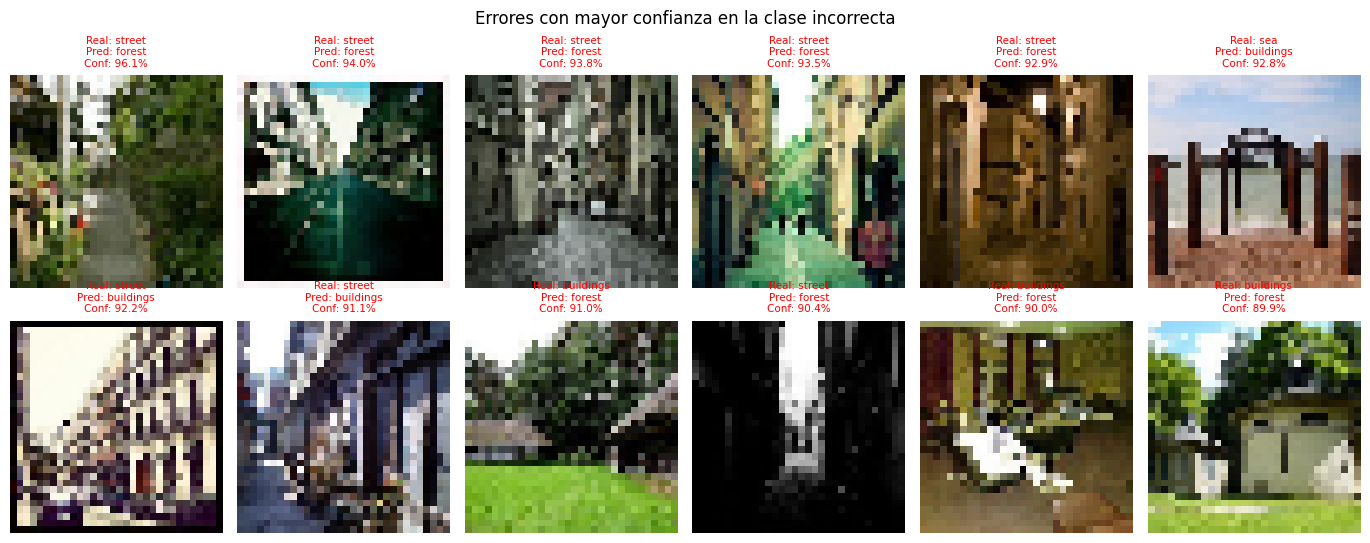

In [10]:
# Probabilidades para todo el test (shape: n_test x 6)
probs_test = model.predict(X_test, verbose=0)
y_pred_arr = np.array(y_pred)

# Índices donde el modelo se equivoca
wrong_mask = (y_pred_arr != y_test)
wrong_idx  = np.where(wrong_mask)[0]

# Confianza = probabilidad asignada a la clase predicha (incorrecta)
wrong_conf = probs_test[wrong_idx].max(axis=1)

# Ordenamos por confianza descendente: los errores más 'seguros' del modelo
order         = np.argsort(wrong_conf)[::-1]
top_wrong_idx = wrong_idx[order]

print(f'Total errores: {len(wrong_idx)} de {len(y_test)} ({len(wrong_idx)/len(y_test)*100:.1f}%)')
print(f'Mostramos los 12 errores con mayor confianza en la clase incorrecta:')

# ── Visualización ─────────────────────────────────────────────
n_show  = min(12, len(top_wrong_idx))
n_cols  = 6
n_rows  = (n_show - 1) // n_cols + 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.3, n_rows * 2.8))
axes = np.array(axes).flatten()

for ax, idx in zip(axes, top_wrong_idx[:n_show]):
    ax.imshow(X_test_raw[idx])
    true_name = le.inverse_transform([y_test[idx]])[0]
    pred_name = le.inverse_transform([y_pred_arr[idx]])[0]
    conf      = probs_test[idx].max() * 100
    ax.set_title(
        f'Real: {true_name}\nPred: {pred_name}\nConf: {conf:.1f}%',
        fontsize=7.5, color='red'
    )
    ax.axis('off')

for ax in axes[n_show:]:
    ax.axis('off')

plt.suptitle('Errores con mayor confianza en la clase incorrecta', fontsize=12)
plt.tight_layout()
plt.show()

### Ejercicio EXTRA: 

Aumenta la resolución y repite el ejercicio con la misma topología de red

In [11]:
# ── Recargamos las imágenes a 64x64 ─────────────────────────
print('Cargando train a 64x64...')
X_train_hq_raw, _ = read_data(TRAIN_PATH, reshape_dim=(64, 64))

print('Cargando test a 64x64...')
X_test_hq_raw,  _ = read_data(TEST_PATH,  reshape_dim=(64, 64))

# Escalado
X_train_hq = X_train_hq_raw.astype('float32') / 255
X_test_hq  = X_test_hq_raw.astype('float32')  / 255

print(f'\nX_train_hq: {X_train_hq.shape}')
print(f'X_test_hq:  {X_test_hq.shape}')

# ── Misma topología, solo cambia input_shape ─────────────────
#
# Con 64x64 el flujo de resolución es:
#   Conv2D(32, 5x5, Same)  -> 64x64x32
#   MaxPool2D(2x2)         -> 32x32x32
#   Conv2D(64, 3x3, Same)  -> 32x32x64
#   MaxPool2D(2x2)         -> 16x16x64
#   Flatten                -> 16*16*64 = 16384 features  (x4 respecto a 32x32)

model_hq = Sequential()

model_hq.add(Conv2D(filters=32, kernel_size=(5, 5), padding='Same',
                    activation='relu', input_shape=(64, 64, 3)))
model_hq.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))  # -> 32x32x32
model_hq.add(Dropout(rate=0.25))

model_hq.add(Conv2D(filters=64, kernel_size=(3, 3), padding='Same',
                    activation='relu'))
model_hq.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))  # -> 16x16x64
model_hq.add(Dropout(rate=0.25))

print('Entrada a Flatten:', model_hq.output_shape)
model_hq.add(Flatten())         # 16*16*64 = 16384 features
print('Salida de Flatten:', model_hq.output_shape)
model_hq.add(Dense(256, activation='relu'))
model_hq.add(Dropout(rate=0.5))
model_hq.add(Dense(NUM_CLASSES, activation='softmax'))

optimizer_hq = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
model_hq.compile(
    optimizer=optimizer_hq,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_hq.summary()

Cargando train a 64x64...
Cargando test a 64x64...

X_train_hq: (14034, 64, 64, 3)
X_test_hq:  (3000, 64, 64, 3)
Entrada a Flatten: (None, 16, 16, 64)
Salida de Flatten: (None, 16384)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,217,030 (16.09 MB)

 Trainable params: 4,217,030 (16.09 MB)

 Non-trainable params: 0 (0.00 B)